# Chapter 44 — Logarithmic Scales

> **Prerequisites:** ch043 (Logarithms Intuition), ch042 (Exponential Growth), ch036 (Scientific Notation)  
> **You will learn:**
> - When and why to use logarithmic axes in plots
> - How to read log-scale graphs without misinterpreting them
> - Real-world logarithmic scales: decibels, Richter, pH, musical pitch, complexity classes
> - The difference between semilog and log-log plots
> - How to identify power laws and exponentials visually on log scales
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A logarithmic scale replaces equal *additive* spacing with equal *multiplicative* spacing. On a standard number line, the distance from 1 to 2 equals the distance from 100 to 101. On a log scale, the distance from 1 to 10 equals the distance from 10 to 100 — both are one "decade."

**Why this matters:** When data spans multiple orders of magnitude, a linear scale is nearly useless — the small values cluster at the origin and the large values dominate the display. A log scale gives each factor of 10 equal visual real estate.

**Two types of log-scale plots:**
1. **Semilog plot (one log axis):** x-axis linear, y-axis logarithmic (or vice versa). An exponential curve `y = a·e^(kx)` appears as a straight line.
2. **Log-log plot (both axes log):** A power law `y = a·x^p` appears as a straight line with slope `p`.

**Key applications:**
- **Decibels:** sound intensity, signal strength, amplifier gain.
- **Richter / moment magnitude:** earthquake energy.
- **pH:** acidity (`pH = -log₁₀[H⁺]`).
- **Stellar magnitude:** brightness of stars.
- **Algorithm complexity:** the gap between `O(n)` and `O(2^n)` is only legible on a log scale.
- **Financial returns:** percentage returns compound — a log scale shows them accurately.

**Common misconception:** Equal visual distance on a log scale does NOT mean equal absolute difference. It means equal *ratio*. Reading a log-scale chart as if it were linear leads to badly wrong conclusions about how large the differences actually are.

---

## 2. Intuition & Mental Models

**Physical analogy:** A piano keyboard is a logarithmic scale of frequency. Each octave doubles the frequency, yet each octave spans the same physical distance on the keyboard. The interval from A2 (110 Hz) to A3 (220 Hz) looks the same as A3 to A4 (440 Hz), even though the second interval spans twice as many Hz.

**Computational analogy:** Think of log-scale as "counting digits instead of counting magnitude." On a log₁₀ scale, 1 and 10 are distance 1 apart (one digit). 10 and 100 are also distance 1 apart (one digit). But in absolute terms, 10 and 100 are 90 units apart while 1 and 10 are only 9. The log scale is measuring *ratios*, not differences.

**Recall from ch043:** `log₁₀(x)` gives the "order of magnitude" of `x`. On a log₁₀ plot, the y-axis tick at position `k` represents `10^k`. Gridlines at 1, 10, 100, 1000 are equally spaced.

**Slope on a log-log plot:** If `log(y) = p·log(x) + c`, then `y = e^c · x^p`. The slope `p` is literally the exponent in the power law. This is how physicists and engineers discover power laws from data — plot log vs log, measure the slope.

---

## 3. Visualization

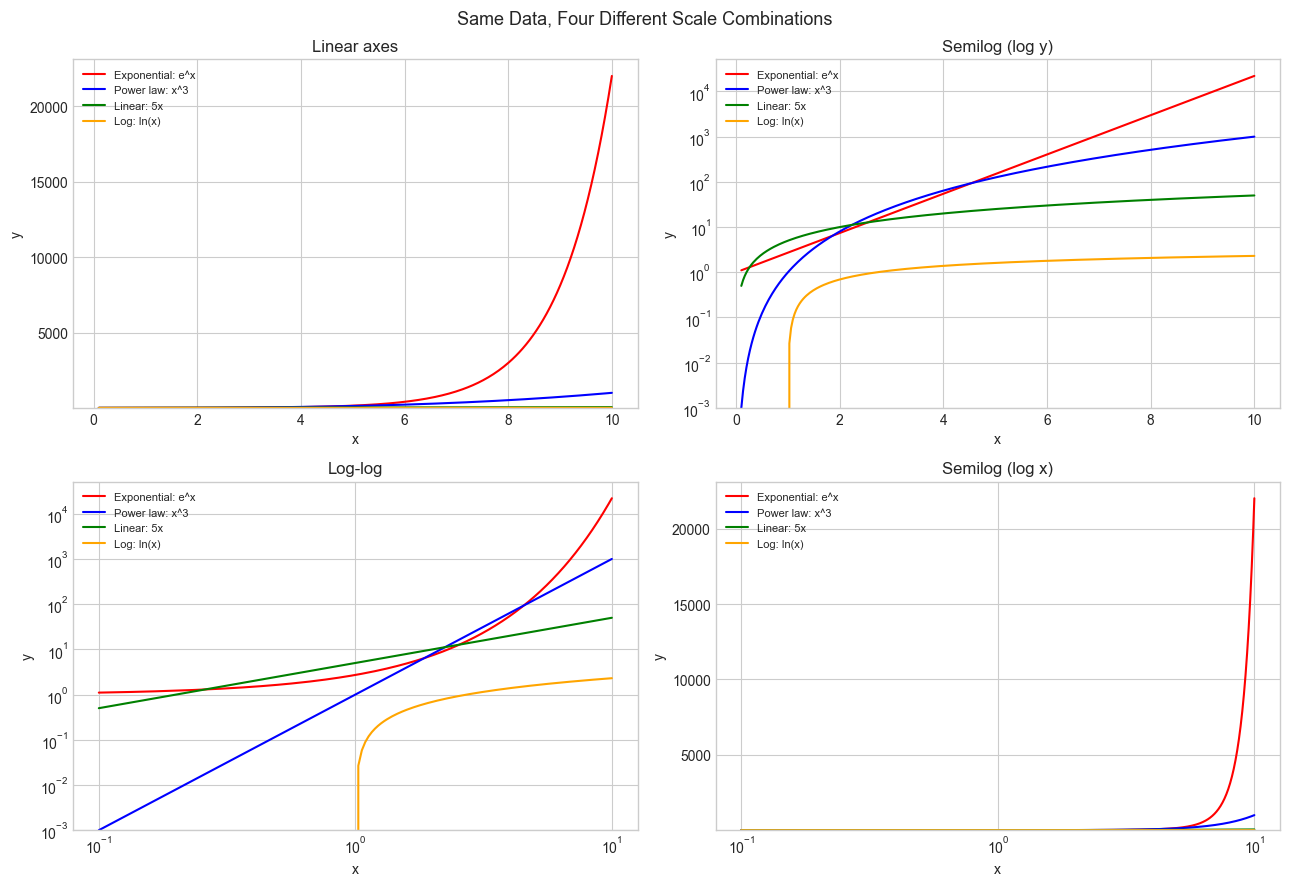

Key observations:
  Semilog (log y): exponential → straight line
  Log-log:         power law   → straight line (slope = exponent)


In [1]:
# --- Visualization: Linear vs log-scale axes —  when to use which ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(0.1, 10, 300)

datasets = {
    'Exponential: e^x':  np.exp(x),
    'Power law: x^3':    x**3,
    'Linear: 5x':        5 * x,
    'Log: ln(x)':        np.log(x),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
titles = ['Linear axes', 'Semilog (log y)', 'Log-log', 'Semilog (log x)']
plot_fns = [
    lambda ax: ax.set_xscale('linear') or ax.set_yscale('linear'),
    lambda ax: ax.set_yscale('log'),
    lambda ax: (ax.set_xscale('log'), ax.set_yscale('log')),
    lambda ax: ax.set_xscale('log'),
]
colors = ['red', 'blue', 'green', 'orange']

for idx, (ax, title, setup) in enumerate(zip(axes.flat, titles, plot_fns)):
    setup(ax)
    for (label, y), color in zip(datasets.items(), colors):
        try:
            ax.plot(x, y, label=label, color=color, linewidth=1.5)
        except Exception:
            pass
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=1e-3)

plt.suptitle('Same Data, Four Different Scale Combinations', fontsize=13)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  Semilog (log y): exponential → straight line")
print("  Log-log:         power law   → straight line (slope = exponent)")

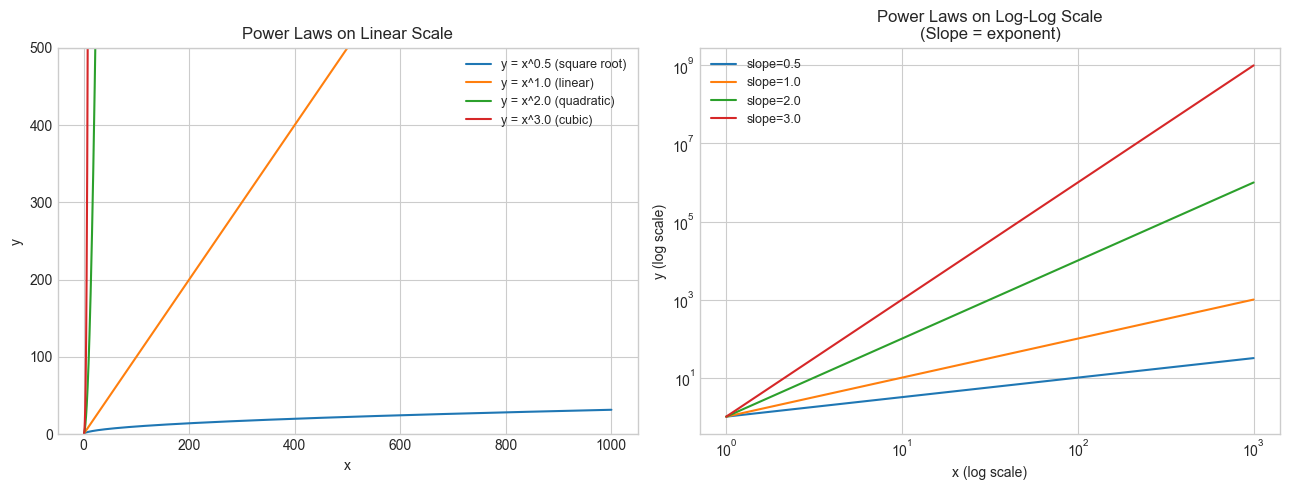

In [2]:
# --- Visualization: Reading a log-log plot — measuring the power law exponent ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Generate three power laws with different exponents
x = np.logspace(0, 3, 200)
power_laws = [(0.5, 'y = x^0.5 (square root)'),
              (1.0, 'y = x^1.0 (linear)'),
              (2.0, 'y = x^2.0 (quadratic)'),
              (3.0, 'y = x^3.0 (cubic)')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for p, label in power_laws:
    y = x**p
    axes[0].plot(x, y, label=label)
    axes[1].loglog(x, y, label=f'slope={p}')

axes[0].set_title('Power Laws on Linear Scale')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_ylim(0, 500)
axes[0].legend(fontsize=9)

axes[1].set_title('Power Laws on Log-Log Scale\n(Slope = exponent)')
axes[1].set_xlabel('x (log scale)')
axes[1].set_ylabel('y (log scale)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

### Semilog plot analysis

If the relationship is exponential: `y = a · b^x`, then:
```
log(y) = log(a) + x · log(b)
       = (intercept) + x · (slope)
```
Semilog (log y axis) → straight line. Slope = `log(b)`, intercept = `log(a)`.

### Log-log plot analysis

If the relationship is a power law: `y = a · x^p`, then:
```
log(y) = log(a) + p · log(x)
       = (intercept) + p · (slope)
```
Log-log → straight line. **Slope = `p` (the exponent directly)**.

### Real-world log scales

```
Decibels:      dB = 10 × log₁₀(P / P_ref)    (power ratio)
               dB = 20 × log₁₀(A / A_ref)    (amplitude ratio)

pH:            pH = -log₁₀([H⁺])              ([H⁺] = hydrogen ion concentration)

Richter:       M = log₁₀(A / A₀)             (amplitude relative to reference)
               Energy: E ∝ 10^(1.5M)          (energy scales with 10^(1.5) per unit magnitude)

Musical pitch: f = f₀ × 2^(n/12)             (n = number of semitones above f₀)
               → semitones = 12 × log₂(f / f₀)
```

In [3]:
# --- Worked examples: real log scales ---
import numpy as np

# Decibels
print("=== Decibels ===")
P_ref = 1e-12  # reference power (hearing threshold)
for name, P in [('Whisper', 1e-10), ('Conversation', 1e-6), ('Concert', 1e-1)]:
    dB = 10 * np.log10(P / P_ref)
    print(f"  {name:15s}: P={P:.1e} W → {dB:.0f} dB")

print("\n+10 dB = 10× power:")
print(f"  60 dB + 10 dB = 70 dB → power ratio: {10**(70/10 - 60/10):.0f}×")

# pH
print("\n=== pH ===")
for name, H in [('Battery acid', 1e-1), ('Lemon juice', 1e-2), 
                 ('Neutral water', 1e-7), ('Bleach', 1e-13)]:
    pH = -np.log10(H)
    print(f"  {name:15s}: [H⁺]={H:.1e} mol/L → pH={pH:.1f}")

# Richter
print("\n=== Richter Scale (energy ratio) ===")
for M in [3, 5, 7, 9]:
    E_ratio = 10 ** (1.5 * M)
    print(f"  M={M}: energy ratio vs M=0 is {E_ratio:.2e}")
print(f"\n  M=9 vs M=7: energy ratio = {10**(1.5*(9-7)):.0f}×  (not 2×, not 100×!)")

# Musical pitch
print("\n=== Musical Semitones ===")
A4 = 440  # Hz
for name, semitones in [('A4', 0), ('A5 (octave up)', 12), 
                         ('Middle C', -9), ('Concert pitch A3', -12)]:
    freq = A4 * 2 ** (semitones / 12)
    print(f"  {name:22s}: {semitones:4d} semitones from A4 → {freq:.2f} Hz")

=== Decibels ===
  Whisper        : P=1.0e-10 W → 20 dB
  Conversation   : P=1.0e-06 W → 60 dB
  Concert        : P=1.0e-01 W → 110 dB

+10 dB = 10× power:
  60 dB + 10 dB = 70 dB → power ratio: 10×

=== pH ===
  Battery acid   : [H⁺]=1.0e-01 mol/L → pH=1.0
  Lemon juice    : [H⁺]=1.0e-02 mol/L → pH=2.0
  Neutral water  : [H⁺]=1.0e-07 mol/L → pH=7.0
  Bleach         : [H⁺]=1.0e-13 mol/L → pH=13.0

=== Richter Scale (energy ratio) ===
  M=3: energy ratio vs M=0 is 3.16e+04
  M=5: energy ratio vs M=0 is 3.16e+07
  M=7: energy ratio vs M=0 is 3.16e+10
  M=9: energy ratio vs M=0 is 3.16e+13

  M=9 vs M=7: energy ratio = 1000×  (not 2×, not 100×!)

=== Musical Semitones ===
  A4                    :    0 semitones from A4 → 440.00 Hz
  A5 (octave up)        :   12 semitones from A4 → 880.00 Hz
  Middle C              :   -9 semitones from A4 → 261.63 Hz
  Concert pitch A3      :  -12 semitones from A4 → 220.00 Hz


---

## 5. Python Implementation

In [4]:
# --- Implementation: Tools for log-scale analysis ---
import numpy as np

def fit_power_law(x, y):
    """
    Fit a power law y = a * x^p to data using log-log linearization.

    Strategy: take log of both sides, fit a line, recover a and p.
    Requires x > 0, y > 0.

    Args:
        x: array of positive x values
        y: array of positive y values

    Returns:
        a: coefficient (float)
        p: exponent (float)
    """
    log_x = np.log(x)
    log_y = np.log(y)
    # Linear fit: log_y = log(a) + p * log_x
    coeffs = np.polyfit(log_x, log_y, 1)  # slope, intercept
    p = coeffs[0]
    a = np.exp(coeffs[1])
    return a, p


def fit_exponential(x, y):
    """
    Fit an exponential y = a * e^(k*x) using semilog linearization.

    Strategy: take log of y, fit a line in (x, log_y), recover a and k.
    Requires y > 0.

    Args:
        x: array of x values
        y: array of positive y values

    Returns:
        a: initial value (float)
        k: growth rate (float)
    """
    log_y = np.log(y)
    coeffs = np.polyfit(x, log_y, 1)
    k = coeffs[0]
    a = np.exp(coeffs[1])
    return a, k


# --- Validate on known data ---
np.random.seed(1)
x = np.linspace(1, 100, 80)

# Test power law: y = 2 * x^2.5
TRUE_A_PL, TRUE_P = 2.0, 2.5
y_power = TRUE_A_PL * x**TRUE_P * (1 + np.random.normal(0, 0.03, len(x)))
a_hat, p_hat = fit_power_law(x, y_power)
print(f"Power law fit:      a={TRUE_A_PL}, p={TRUE_P}")
print(f"  Estimated:        a={a_hat:.4f}, p={p_hat:.4f}")

# Test exponential: y = 5 * e^(0.1 * x)
TRUE_A_EX, TRUE_K = 5.0, 0.1
y_exp = TRUE_A_EX * np.exp(TRUE_K * x) * (1 + np.random.normal(0, 0.02, len(x)))
a_hat_e, k_hat = fit_exponential(x, y_exp)
print(f"\nExponential fit:    a={TRUE_A_EX}, k={TRUE_K}")
print(f"  Estimated:        a={a_hat_e:.4f}, k={k_hat:.4f}")

Power law fit:      a=2.0, p=2.5
  Estimated:        a=1.9825, p=2.5027

Exponential fit:    a=5.0, k=0.1
  Estimated:        a=5.0050, k=0.1000


---

## 6. Experiments

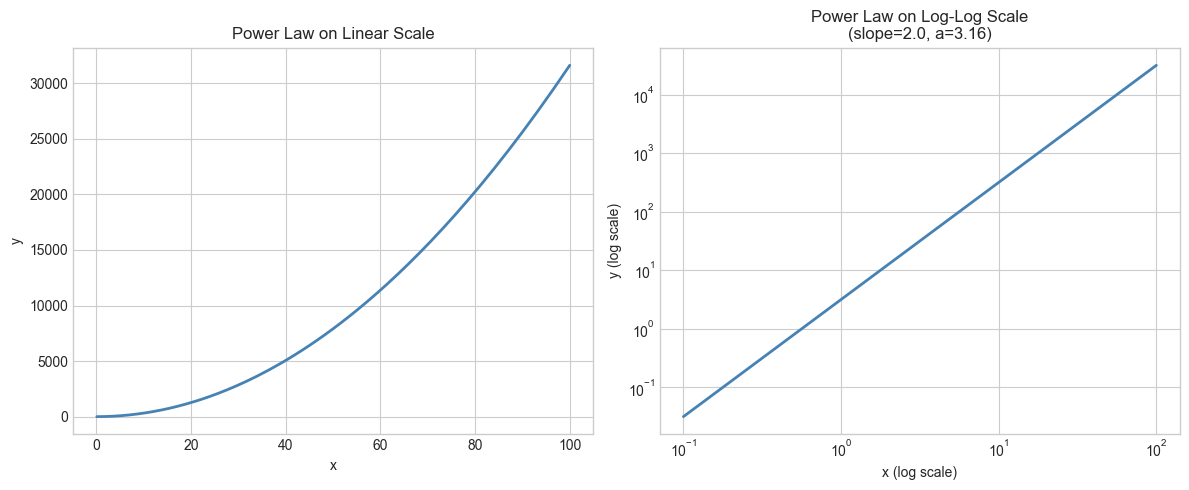

Power law: y = 3.16 × x^2.0
On log-log plot: log(y) = 0.50 + 2.0 × log(x)
Slope on log-log = exponent in power law = 2.0


In [5]:
# --- Experiment 1: What does a straight line on a log-log plot mean? ---
# Hypothesis: Any straight line on a log-log plot is a power law.
# The slope is the exponent. The y-intercept gives the coefficient.
# Try changing: SLOPE and INTERCEPT_LOG

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

SLOPE          = 2.0    # <-- modify this (try 0.5, -1, 3)
INTERCEPT_LOG  = 0.5    # <-- modify this (log₁₀ of the coefficient a)

x = np.logspace(-1, 2, 200)  # 0.1 to 100
a = 10**INTERCEPT_LOG
y = a * x**SLOPE

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x, y, color='steelblue', linewidth=2)
axes[0].set_title('Power Law on Linear Scale')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].loglog(x, y, color='steelblue', linewidth=2)
axes[1].set_title(f'Power Law on Log-Log Scale\n(slope={SLOPE}, a={a:.2f})')
axes[1].set_xlabel('x (log scale)')
axes[1].set_ylabel('y (log scale)')

plt.tight_layout()
plt.show()

print(f"Power law: y = {a:.2f} × x^{SLOPE}")
print(f"On log-log plot: log(y) = {INTERCEPT_LOG:.2f} + {SLOPE} × log(x)")
print(f"Slope on log-log = exponent in power law = {SLOPE}")

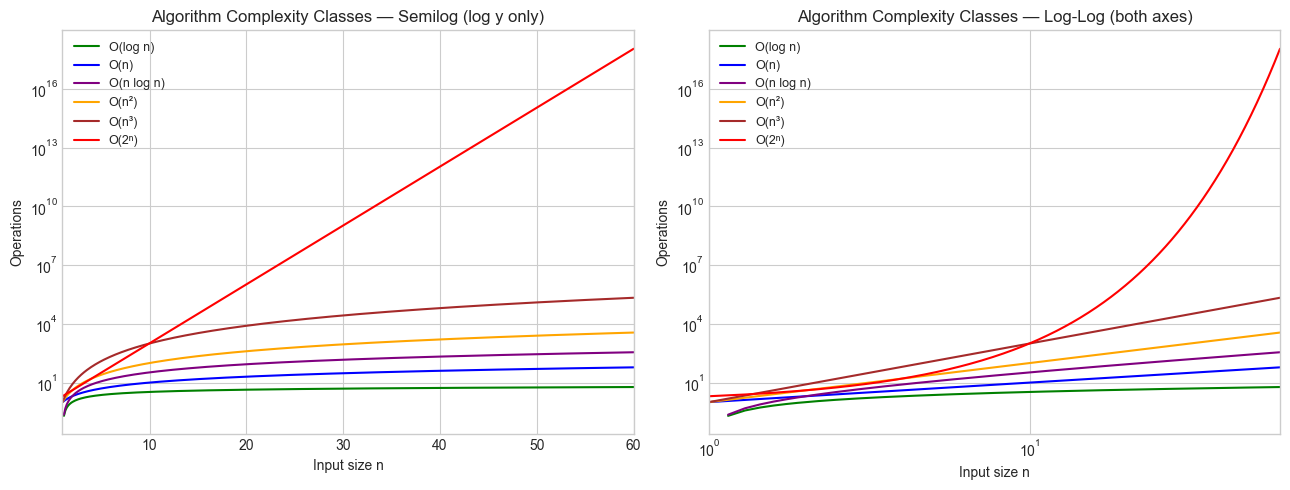

On log-log: polynomial complexities are straight lines (slope = exponent).
O(2^n) curves upward on semilog — it is super-polynomial.


In [6]:
# --- Experiment 2: Algorithm complexity on log scale ---
# Hypothesis: On a log-log plot, O(n^k) algorithms are straight lines
# with slope k. O(2^n) curves up steeply even on a log-y scale.
# Try changing: MAX_N

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

MAX_N = 60  # <-- modify this

n = np.linspace(1, MAX_N, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

complexities = [
    (np.log2(n),  'O(log n)',  'green'),
    (n,           'O(n)',      'blue'),
    (n * np.log2(np.maximum(n,1)), 'O(n log n)', 'purple'),
    (n**2,        'O(n²)',     'orange'),
    (n**3,        'O(n³)',     'brown'),
    (2**n,        'O(2ⁿ)',     'red'),
]

for ops, label, color in complexities:
    valid = ops > 0
    axes[0].semilogy(n[valid], ops[valid], label=label, color=color, linewidth=1.5)
    axes[1].loglog(n[valid], ops[valid],   label=label, color=color, linewidth=1.5)

for ax, title in zip(axes, ['Semilog (log y only)', 'Log-Log (both axes)']):
    ax.set_title(f'Algorithm Complexity Classes — {title}')
    ax.set_xlabel('Input size n')
    ax.set_ylabel('Operations')
    ax.legend(fontsize=9)
    ax.set_xlim(1, MAX_N)

plt.tight_layout()
plt.show()

print("On log-log: polynomial complexities are straight lines (slope = exponent).")
print("O(2^n) curves upward on semilog — it is super-polynomial.")

---

## 7. Exercises

**Easy 1.** On a log-log plot you observe a straight line from (1, 3) to (100, 300). What power law does this represent? Compute the slope and coefficient.

**Easy 2.** An amplifier has a gain of 40 dB. If the input signal has amplitude 0.01 V, what is the output amplitude? *(Use: dB = 20 × log₁₀(A_out / A_in).)*

**Medium 1.** The following dataset represents city population ranks and sizes (Zipf's Law — a famous power law). Fit the power law on a log-log scale and report the exponent:
```python
ranks = [1, 2, 3, 4, 5, 10, 20, 50, 100]
populations = [8_336_000, 3_857_000, 2_693_000, 2_147_000, 1_645_000,
               675_000, 309_000, 114_000, 50_000]
```

**Medium 2.** Create a function `semilog_vs_loglog_classify(x, y)` that:
1. Fits both an exponential (semilog) and a power law (log-log) to the data
2. Computes the residuals of each fit on the transformed scale
3. Returns `'exponential'` or `'power_law'` based on which fit has lower residuals

**Hard.** The frequency of the `n`-th harmonic above a fundamental frequency `f₀` is `n × f₀`. On a standard linear frequency axis, harmonics pile up at multiples of `f₀`. On a log-frequency axis, they are *not* equally spaced. Derive the formula for the position of the `n`-th harmonic on a log₂ scale (in octaves above `f₀`) and explain why equal-tempered musical scales use 12-tone logarithmic divisions.

---

## 8. Mini Project: Internet Traffic and Zipf's Law

In [ ]:
# --- Mini Project: Detecting Power Laws in Real-World Data ---
#
# Problem:
#   Zipf's Law states that in many natural datasets, the r-th most common item
#   has frequency proportional to 1/r^α (a power law with α ≈ 1).
#   This appears in word frequencies, city sizes, income distributions,
#   website traffic, and more.
#
#   Your task: Simulate a Zipf-distributed dataset, visualize it on log-log
#   axes, fit the power law, and verify the exponent.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Simulate Zipf distribution: rank r has probability ∝ 1/r^alpha
N_RANKS = 1000   # number of ranks
ALPHA   = 1.2    # true power law exponent

ranks = np.arange(1, N_RANKS + 1)
true_freq = ranks ** (-ALPHA)            # unnormalized
true_prob = true_freq / true_freq.sum()  # normalized probabilities

# Simulate N_SAMPLES draws from this distribution
N_SAMPLES = 100_000
samples = np.random.choice(ranks, size=N_SAMPLES, p=true_prob)

# Count observed frequencies per rank
observed_counts = np.bincount(samples, minlength=N_RANKS + 1)[1:]  # index 0 unused

# Keep only ranks with nonzero counts
nonzero = observed_counts > 0
r = ranks[nonzero]
f = observed_counts[nonzero]

# TODO 1: Fit a power law on the log-log scale
def fit_power_law(x, y):
    coeffs = np.polyfit(np.log(x), np.log(y), 1)
    return np.exp(coeffs[1]), coeffs[0]

a_hat, alpha_hat = fit_power_law(r, f)

# TODO 2: Plot raw counts and fitted line on log-log axes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(r, f, s=3, alpha=0.4, color='gray', label='Observed counts')
r_fit = np.linspace(r.min(), r.max(), 300)
ax.plot(r_fit, a_hat * r_fit**alpha_hat, color='red', linewidth=2,
        label=f'Fit: f ∝ r^{alpha_hat:.3f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Zipf Distribution: Rank vs Frequency (Log-Log)')
ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.legend()

# TODO 3: Residuals on log-log scale
ax = axes[1]
log_r = np.log(r)
log_f = np.log(f)
log_f_fit = np.log(a_hat) + alpha_hat * log_r
residuals = log_f - log_f_fit
ax.scatter(log_r, residuals, s=3, alpha=0.4, color='steelblue')
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuals (log scale fit)')
ax.set_xlabel('log(Rank)')
ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f"True exponent:      α = {ALPHA:.4f}")
print(f"Estimated exponent: α̂ = {-alpha_hat:.4f}  (reported as negative slope → positive exponent)")
print(f"\nZipf's law is a power law: frequency ∝ rank^(-α)")
print(f"The log-log slope is -{-alpha_hat:.4f} ≈ -{ALPHA:.4f}.")

---

## 9. Chapter Summary & Connections

- A logarithmic axis replaces equal-distance (additive) spacing with equal-ratio (multiplicative) spacing. It compresses vast ranges into readable plots.
- Semilog plot (one log axis): exponential relationships appear as straight lines. Slope = growth rate.
- Log-log plot (both axes log): power law relationships appear as straight lines. Slope = exponent.
- Real-world log scales — decibels, pH, Richter, musical pitch — all exploit the compression property to make enormous ranges tractable.
- Fitting parameters from log-transformed data (log-linearization) is a practical technique appearing throughout data analysis.

**Backward connection:** This chapter applies ch043 (Logarithms Intuition) to measurement and visualization. The power law fitting reuses `np.polyfit` *(introduced in the mini project there)* and connects to ch036 (Scientific Notation) for the multi-decade scale plots.

**Forward connections:**
- ch045 (Computational Logarithms) will implement `ln(x)` numerically using Taylor series and Newton's method.
- Power law fitting via log-log linearization reappears formally in ch282 (Regression) as a special case of linear regression on transformed variables.
- The complexity plots here — showing `O(log n)` vs `O(2^n)` — connect directly to ch047 (Orders of Magnitude) and the entire algorithm analysis thread throughout the book.
- Zipf's law and heavy-tailed distributions reappear in ch293 (Clustering) and ch298 (Large Scale Data) as a fundamental challenge in modeling real-world data.

**Going deeper:** *The Signal and the Noise* (Nate Silver), Chapter 3 — a non-technical discussion of why log scales matter for understanding risk. For the mathematical theory: *Introduction to the Theory of Statistics* (Mood, Graybill, Boes), Section on transformations.